UTS DATA MINING

NADIA FUTUKHIYATUL HIDAYAH

2304020196



**UPLOAD DATA SET**

Dataset training dan testing diunggah ke Google Colab agar dapat diproses menggunakan Python dalam pembuatan model klasifikasi wine quality.


In [5]:
from google.colab import files

uploaded = files.upload()

Saving data_training.csv to data_training (1).csv
Saving data_testing.csv to data_testing.csv


**Import Library**

Library yang digunakan membantu proses analisis data, visualisasi, preprocessing, pembuatan model machine learning, evaluasi model, dan penyimpanan model.

In [62]:
import pandas as pd
import numpy as np

# visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# model machine learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# evaluasi model
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# simpan model
import joblib

**Membaca Dataset**

Dataset training digunakan untuk melatih model klasifikasi, sedangkan dataset testing digunakan untuk melakukan prediksi quality wine.

In [7]:
train_df = pd.read_csv('data_training.csv')
test_df = pd.read_csv('data_testing.csv')

**Melihat Dataset**

Pengecekan data awal dilakukan untuk memastikan dataset berhasil dibaca serta mengetahui struktur, tipe data, dan jumlah data yang tersedia.

In [8]:
print(train_df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.3             0.740         0.08             1.7      0.094   
1            8.1             0.575         0.22             2.1      0.077   
2           10.1             0.430         0.40             2.6      0.092   
3           12.9             0.500         0.55             2.8      0.072   
4            8.4             0.360         0.32             2.2      0.081   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 10.0                  45.0  0.99576  3.24       0.50   
1                 12.0                  65.0  0.99670  3.29       0.51   
2                 13.0                  52.0  0.99834  3.22       0.64   
3                  7.0                  24.0  1.00012  3.09       0.68   
4                 32.0                  79.0  0.99640  3.30       0.72   

   alcohol  quality    Id  
0      9.8        5  1366  
1      9.2        5   103  
2 

In [9]:
print(test_df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            6.8              0.61         0.04             1.5      0.057   
1            6.9              0.84         0.21             4.1      0.074   
2            7.0              0.58         0.12             1.9      0.091   
3            7.8              0.48         0.68             1.7      0.415   
4           12.5              0.60         0.49             4.3      0.100   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                  5.0                  10.0  0.99525  3.42       0.60   
1                 16.0                  65.0  0.99842  3.53       0.72   
2                 34.0                 124.0  0.99560  3.44       0.48   
3                 14.0                  32.0  0.99656  3.09       1.06   
4                  5.0                  14.0  1.00100  3.25       0.74   

     alcohol    Id  
0   9.500000   222  
1   9.233333  1514  
2  10.500000   417  
3 

**Informasi dataset**

 digunakan untuk mengetahui jumlah data, jumlah kolom, tipe data setiap fitur, serta mendeteksi adanya missing values pada dataset training. Tahap ini membantu memastikan data siap digunakan untuk proses analisis dan pembuatan model klasifikasi.

In [10]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
None


digunakan untuk memastikan struktur data testing sesuai dengan dataset training sehingga model dapat digunakan untuk melakukan prediksi dengan benar.

In [11]:
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         286 non-null    float64
 1   volatile acidity      286 non-null    float64
 2   citric acid           286 non-null    float64
 3   residual sugar        286 non-null    float64
 4   chlorides             286 non-null    float64
 5   free sulfur dioxide   286 non-null    float64
 6   total sulfur dioxide  286 non-null    float64
 7   density               286 non-null    float64
 8   pH                    286 non-null    float64
 9   sulphates             286 non-null    float64
 10  alcohol               286 non-null    float64
 11  Id                    286 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 26.9 KB
None


**UKURAN DATASET**

Kode dibawah digunakan untuk mengetahui ukuran dataset berupa jumlah baris dan kolom pada data training dan data testing. Informasi ini membantu memahami banyaknya data yang akan digunakan dalam proses pelatihan dan prediksi model klasifikasi.

In [12]:
print(train_df.shape)
print(test_df.shape)

(857, 13)
(286, 12)


**Mengecek Missing Values**

Pengecekan missing values dilakukan untuk mengetahui apakah terdapat data kosong yang dapat mempengaruhi performa model klasifikasi.

In [15]:
print(train_df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [16]:
print(test_df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


**Distribusi Quality**



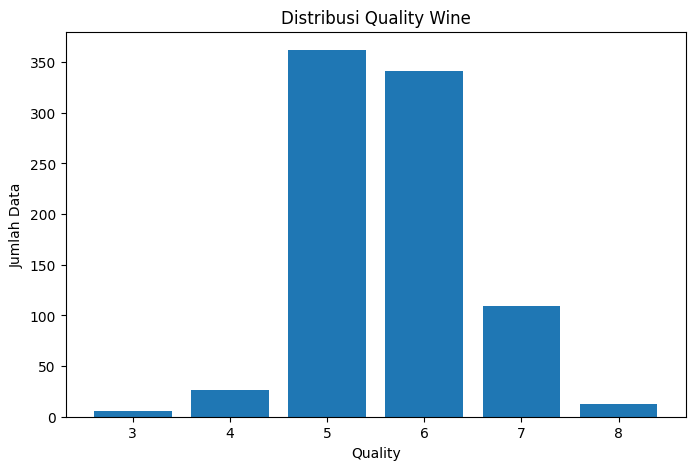

In [17]:
quality_counts = train_df['quality'].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    quality_counts.index,
    quality_counts.values
)

plt.title('Distribusi Quality Wine')
plt.xlabel('Quality')
plt.ylabel('Jumlah Data')

plt.show()

Visualisasi distribusi quality menunjukkan bahwa kategori quality 5 dan 6 memiliki jumlah data paling banyak dibandingkan kategori lainnya sehingga dataset cenderung tidak seimbang.

**Persentase Quality**



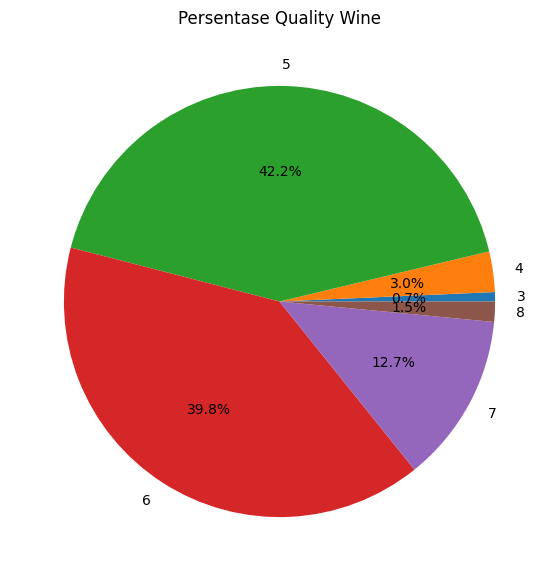

In [18]:
quality_percent = train_df['quality'].value_counts(normalize=True) * 100

quality_percent = quality_percent.sort_index()

plt.figure(figsize=(7,7))

plt.pie(
    quality_percent.values,
    labels=[str(i) for i in quality_percent.index],
    autopct='%1.1f%%'
)

plt.title('Persentase Quality Wine')

plt.show()

Diagram persentase diatas memperlihatkan bahwa sebagian besar data wine berada pada quality menengah, yaitu quality 5 dan 6.

**Histogram Semua Fitur**

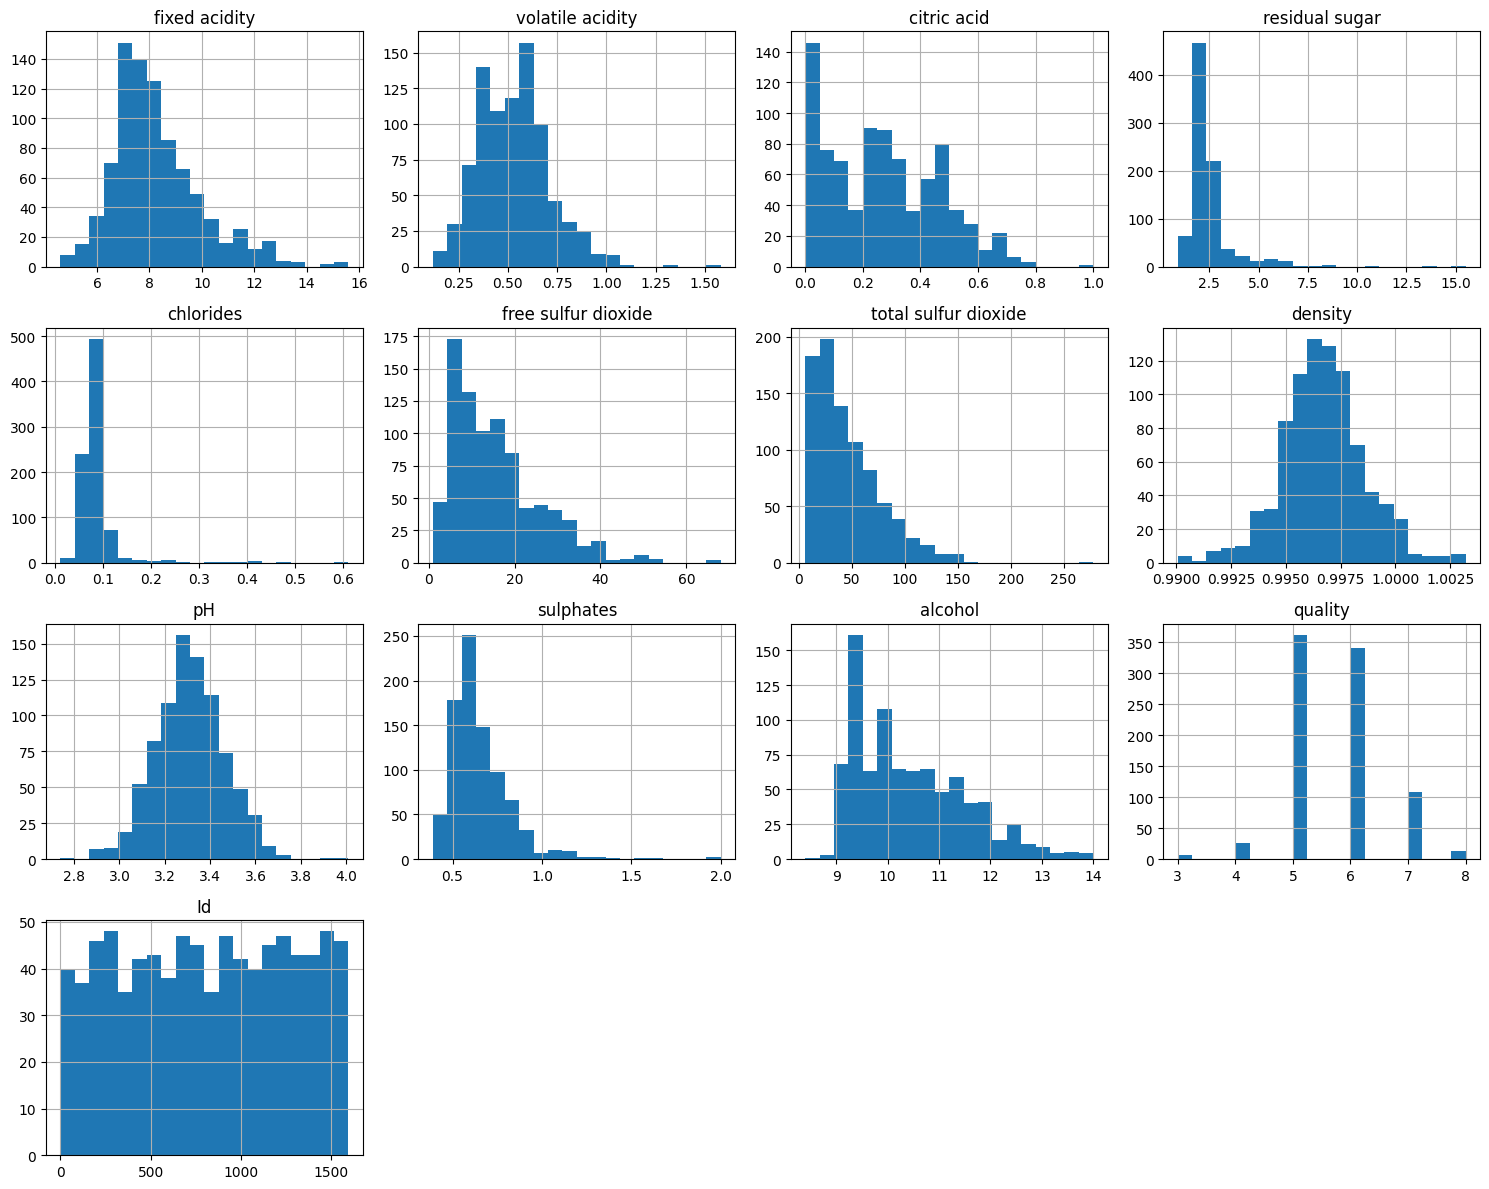

In [19]:
train_df.hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()

plt.show()

Histogram tersebut digunakan untuk melihat persebaran data setiap fitur serta membantu mendeteksi adanya outlier dan pola distribusi data.

**Distribusi Alcohol**



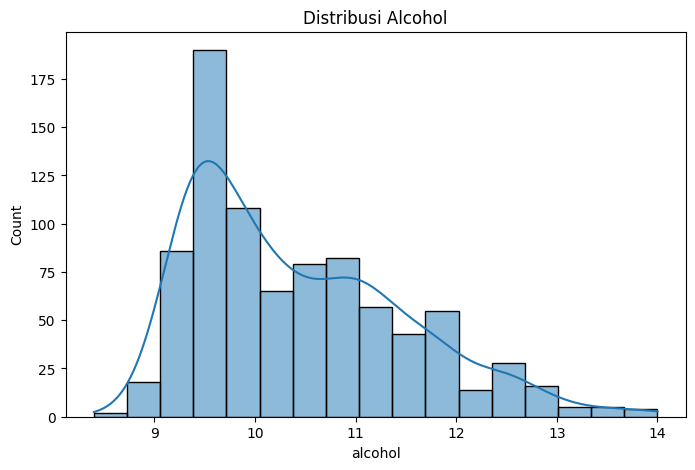

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df['alcohol'],
    kde=True
)

plt.title('Distribusi Alcohol')

plt.show()



Distribusi alcohol menunjukkan persebaran kadar alcohol pada wine dan membantu memahami karakteristik data alcohol.

**Distribusi pH**



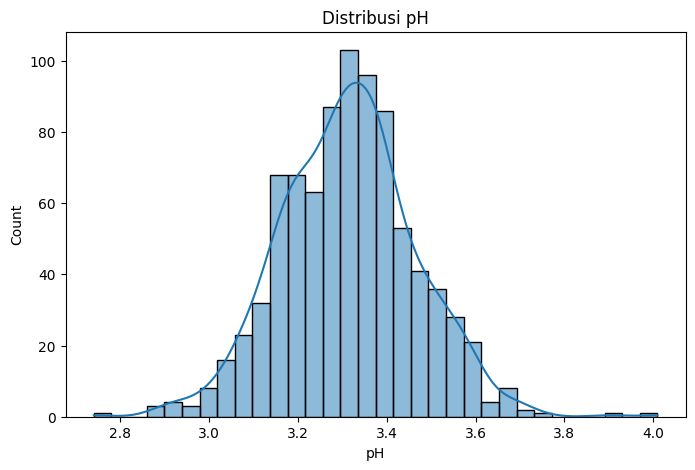

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df['pH'],
    kde=True
)

plt.title('Distribusi pH')

plt.show()


Visualisasi pH digunakan untuk melihat tingkat keasaman wine serta pola persebarannya pada dataset.

**Scatter Plot Alcohol vs Quality**

Scatter plot menunjukkan adanya kecenderungan bahwa semakin tinggi kadar alcohol, quality wine cenderung meningkat.

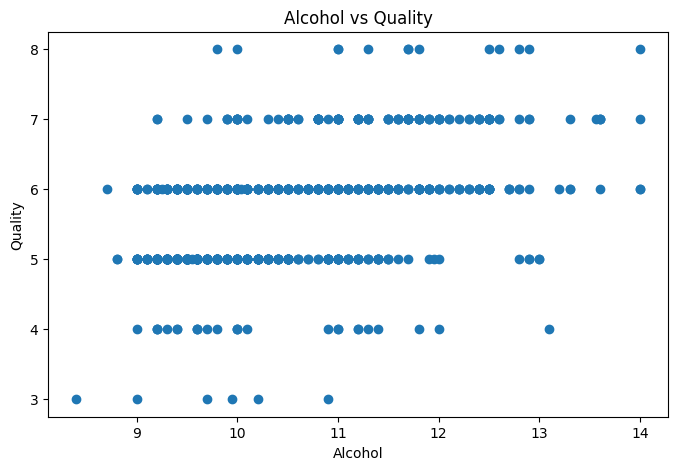

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(
    train_df['alcohol'],
    train_df['quality']
)

plt.xlabel('Alcohol')
plt.ylabel('Quality')

plt.title('Alcohol vs Quality')

plt.show()

**Boxplot Alcohol vs Quality**

Boxplot digunakan untuk melihat median, persebaran data, dan outlier alcohol pada setiap kategori quality wine.

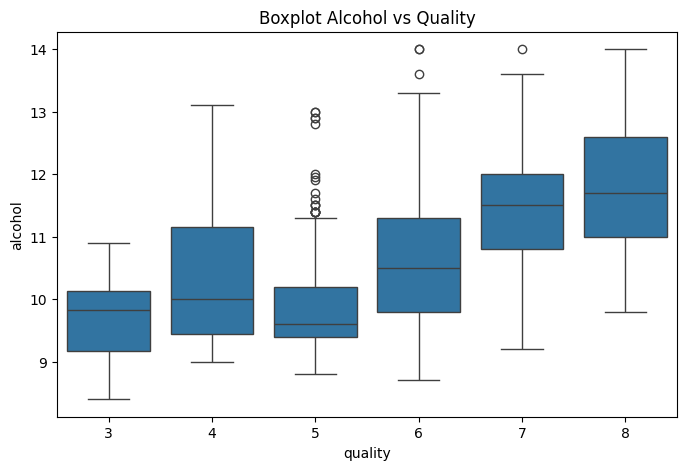

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='quality',
    y='alcohol',
    data=train_df
)

plt.title('Boxplot Alcohol vs Quality')

plt.show()

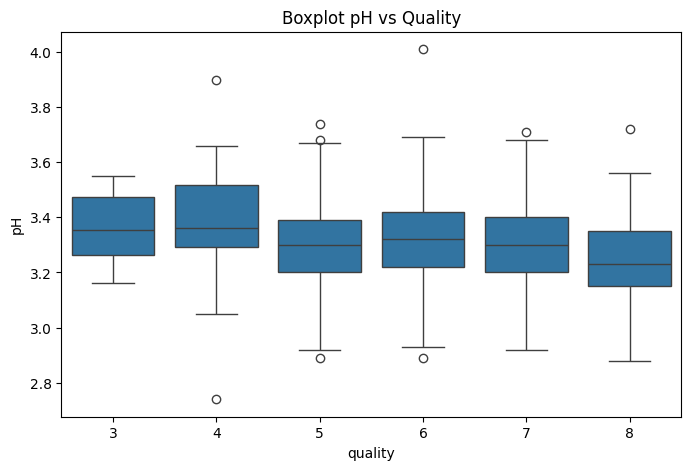

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='quality',
    y='pH',
    data=train_df
)

plt.title('Boxplot pH vs Quality')

plt.show()

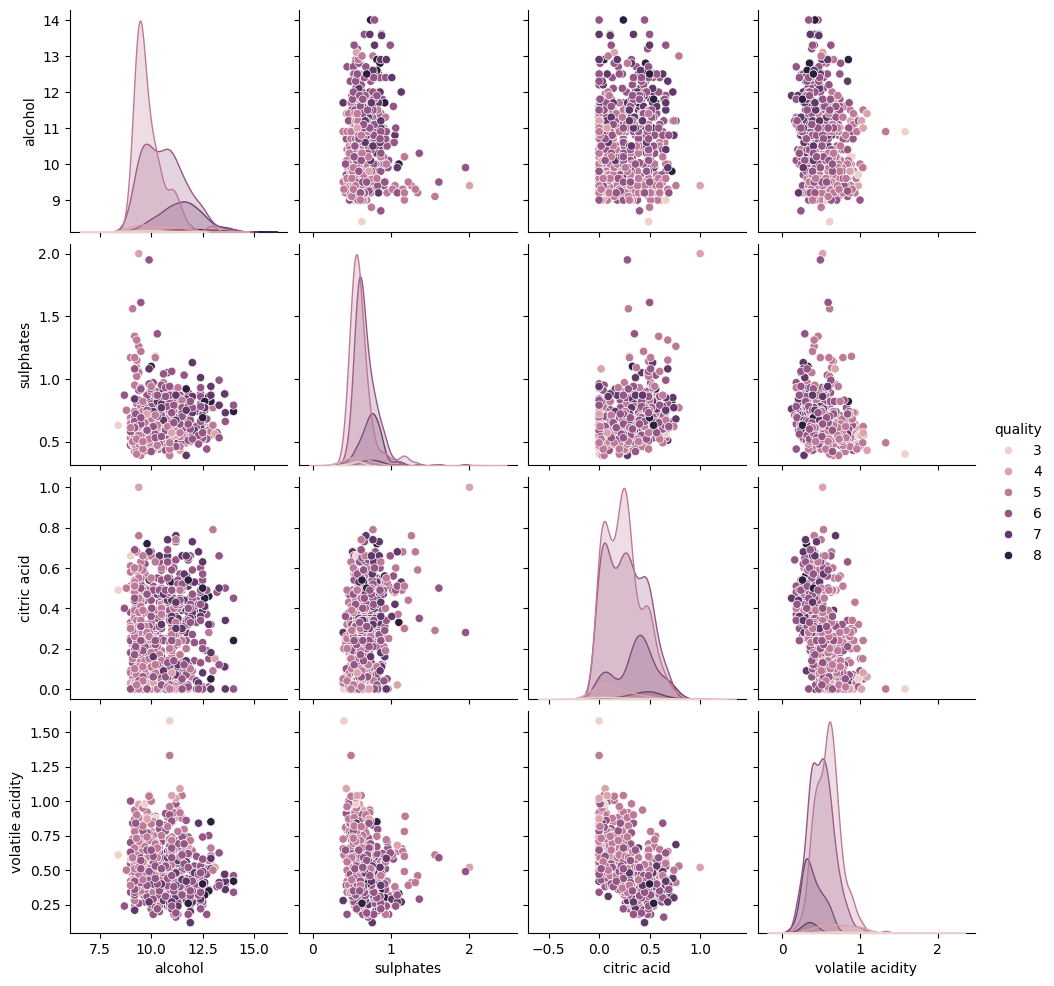

In [28]:
sns.pairplot(
    train_df[
        [
            'alcohol',
            'sulphates',
            'citric acid',
            'volatile acidity',
            'quality'
        ]
    ],
    hue='quality'
)

plt.show()

**Heatmap Korelasi**



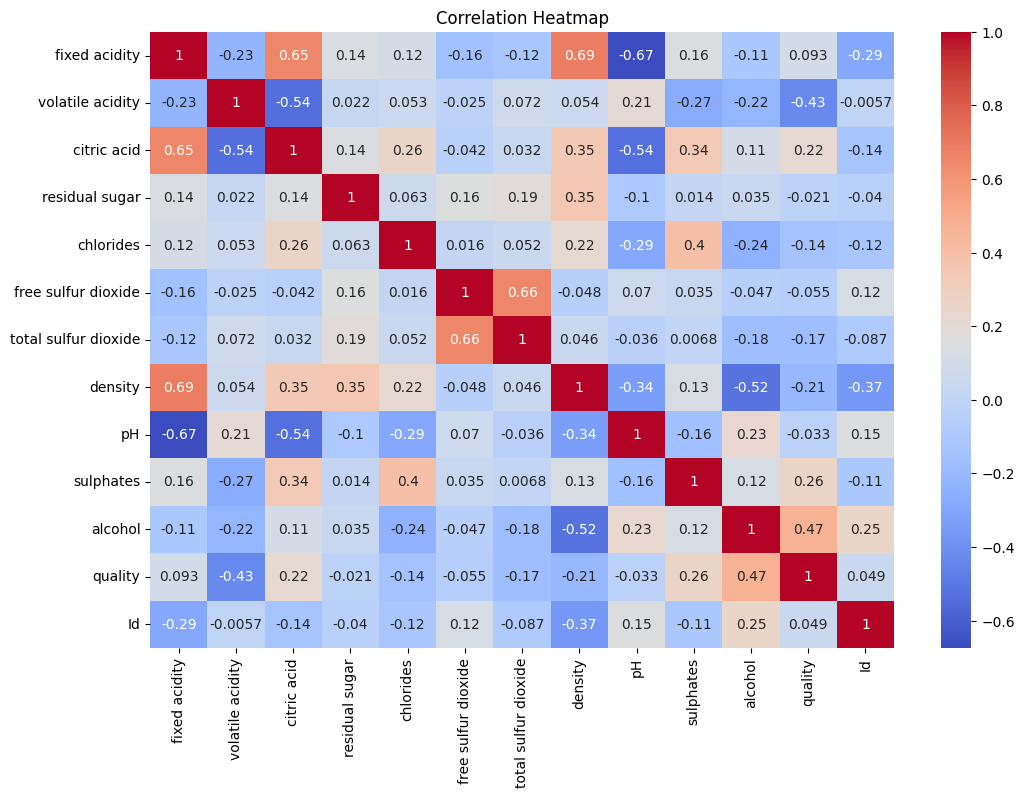

In [29]:
plt.figure(figsize=(12,8))

sns.heatmap(
    train_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()



Heatmap korelasi digunakan untuk mengetahui hubungan antar fitur serta fitur yang paling mempengaruhi quality wine.

**Memisahkan Fitur dan Target**

Data dipisahkan menjadi fitur input dan target quality agar model dapat mempelajari hubungan antar variabel

In [30]:
X = train_df.drop(columns=['quality'])
y = train_df['quality']

**Menyimpan Kolom Id**

Kolom Id disimpan agar dapat digunakan kembali pada file hasil prediksi.

In [31]:
test_ids = test_df['Id']

**Menghapus Kolom Id**

Kolom Id dihapus dari fitur karena tidak berpengaruh terhadap proses klasifikasi.

In [32]:
X = X.drop(columns=['Id'])
X_test = test_df.drop(columns=['Id'])

**Menangani Missing Values**

Missing values ditangani menggunakan nilai rata-rata agar dataset tetap lengkap dan dapat diproses oleh model machine learning.

In [33]:
imputer = SimpleImputer(strategy='mean')

X_imputed = imputer.fit_transform(X)
X_test_imputed = imputer.transform(X_test)

**Feature Scaling**

Feature scaling dilakukan agar seluruh fitur memiliki skala yang seimbang sehingga model dapat bekerja lebih optimal.

In [34]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

**Split Data Training dan Validasi**

Dataset dibagi menjadi data training dan data validasi agar performa model dapat diuji pada data yang belum pernah dipelajari sebelumnya.

In [35]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Model Decision Tree**

Model Decision Tree dibuat untuk membentuk aturan klasifikasi berdasarkan fitur-fitur wine.

In [63]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

**Training Model Decision Tree**

Pada tahap ini model Decision Tree mempelajari pola hubungan antara fitur wine dan quality wine dari data training.

In [64]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

**Prediksi Data Validasi Decision Tree**

Model Decision Tree digunakan untuk memprediksi quality wine pada data validasi.

In [67]:
dt_pred = dt_model.predict(X_val)

**Accuracy Decision Tree**

Nilai accuracy digunakan untuk mengetahui tingkat keberhasilan model Decision Tree dalam melakukan klasifikasi.

In [68]:
dt_accuracy = accuracy_score(y_val, dt_pred)

print("Accuracy Decision Tree :", dt_accuracy)

Accuracy Decision Tree : 0.6046511627906976


**Model Random Forest**

Model Random Forest dibuat untuk menghasilkan klasifikasi yang lebih stabil dengan menggabungkan banyak decision tree.

In [36]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

**Training Model Random Forest**

Model Random Forest mempelajari pola hubungan antara fitur wine dan quality wine dari data training.

In [37]:
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

**Prediksi Data Validasi Random Forest**

Model Random Forest digunakan untuk memprediksi quality wine pada data validasi.

In [38]:
y_pred = model.predict(X_val)

**Accuracy Random Forest**

Nilai accuracy digunakan untuk mengetahui tingkat keberhasilan model Random Forest dalam memprediksi quality wine.

In [39]:
accuracy = accuracy_score(y_val, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.6104651162790697


**Perbandingan Accuracy Model**

Perbandingan accuracy dilakukan untuk mengetahui metode klasifikasi dengan performa terbaik antara Decision Tree dan Random Forest.

In [72]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_val)

dt_accuracy = accuracy_score(y_val, dt_pred)

print("Accuracy Decision Tree :", dt_accuracy)


# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)

rf_accuracy = accuracy_score(y_val, rf_pred)

print("Accuracy Random Forest :", rf_accuracy)


# Perbandingan Accuracy
comparison = pd.DataFrame({
    'Metode': ['Decision Tree', 'Random Forest'],
    'Accuracy': [dt_accuracy, rf_accuracy]
})

print(comparison)

Accuracy Decision Tree : 0.6046511627906976
Accuracy Random Forest : 0.6104651162790697
          Metode  Accuracy
0  Decision Tree  0.604651
1  Random Forest  0.610465


**Visualisasi Perbandingan Accuracy**

Visualisasi digunakan untuk memperjelas perbedaan performa accuracy antar metode klasifikasi.

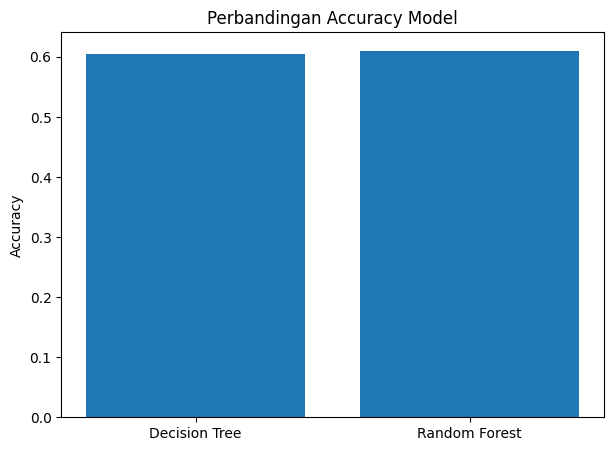

In [73]:
plt.figure(figsize=(7,5))

plt.bar(
    comparison['Metode'],
    comparison['Accuracy']
)

plt.title('Perbandingan Accuracy Model')
plt.ylabel('Accuracy')

plt.show()

Hasil perbandingan menunjukkan bahwa model dengan nilai accuracy tertinggi merupakan model yang paling baik dalam memprediksi quality wine. Pada umumnya, Random Forest menghasilkan accuracy yang lebih tinggi karena menggabungkan banyak decision tree sehingga hasil prediksi lebih stabil dan akurat dibandingkan Decision Tree tunggal.

**Confusion Matrix**

Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah pada masing-masing kategori quality wine.

In [40]:
cm = confusion_matrix(y_val, y_pred)

print(cm)

[[ 0  0  0  1  0  0]
 [ 0  0  5  0  0  0]
 [ 0  0 58 14  1  0]
 [ 0  0 24 40  4  0]
 [ 0  0  0 16  6  0]
 [ 0  0  0  0  2  1]]


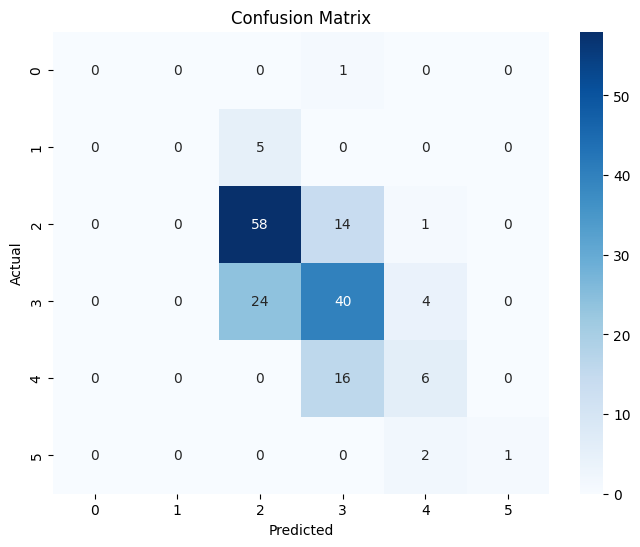

In [41]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

**Classification Report**

Classification report menampilkan precision, recall, dan f1-score untuk mengevaluasi performa model secara lebih rinci.

In [42]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.67      0.79      0.72        73
           6       0.56      0.59      0.58        68
           7       0.46      0.27      0.34        22
           8       1.00      0.33      0.50         3

    accuracy                           0.61       172
   macro avg       0.45      0.33      0.36       172
weighted avg       0.58      0.61      0.59       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Feature Importance**

Feature importance menunjukkan fitur-fitur yang paling berpengaruh dalam menentukan quality wine.

In [43]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                 Feature  Importance
10               alcohol    0.137363
9              sulphates    0.123104
1       volatile acidity    0.112623
6   total sulfur dioxide    0.094480
4              chlorides    0.085591
7                density    0.084497
2            citric acid    0.076568
0          fixed acidity    0.075948
8                     pH    0.075598
3         residual sugar    0.067958
5    free sulfur dioxide    0.066269


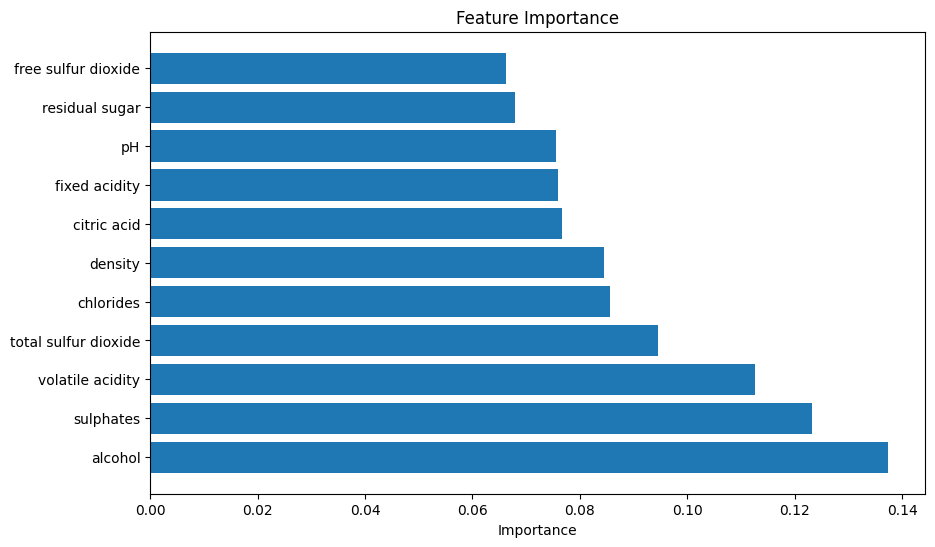

In [44]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('Feature Importance')

plt.xlabel('Importance')

plt.show()

**Prediksi Dataset Testing**

Model digunakan untuk memprediksi quality wine pada dataset testing yang belum memiliki label.

In [47]:
test_predictions = loaded_model.predict(X_test_scaled)

**Visualisasi Hasil Prediksi**

Visualisasi hasil prediksi menunjukkan distribusi quality hasil klasifikasi pada dataset testing.

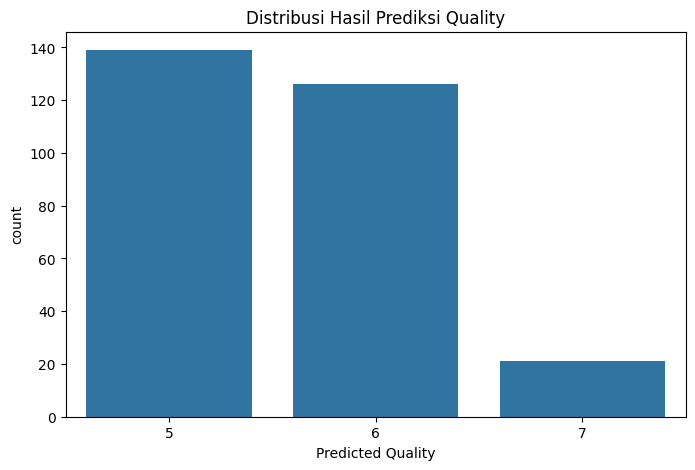

In [48]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=test_predictions
)

plt.title('Distribusi Hasil Prediksi Quality')

plt.xlabel('Predicted Quality')

plt.show()

Mayoritas hasil prediksi berada pada quality 5 dan 6.

**Membuat Submission**

Hasil prediksi disusun dalam format submission yang berisi kolom Id dan quality.

In [53]:
submission = pd.DataFrame({
    'Id': test_ids,
    'quality': test_predictions
})

**Mengambiil 300 Data**

In [57]:
submission_300 = submission.head(300)

**Menampilkan 300 Data**

Sebanyak 300 data hasil prediksi ditampilkan untuk memastikan hasil prediksi berhasil dibuat dengan benar.

In [58]:
pd.set_option('display.max_rows', 300)

print(submission_300)

       Id  quality
0     222        5
1    1514        6
2     417        5
3     754        5
4     516        5
5    1120        7
6     180        5
7      82        5
8     632        6
9     592        5
10    501        7
11   1586        6
12   1096        5
13   1101        6
14   1488        5
15    700        5
16    631        6
17   1022        6
18   1420        5
19    882        7
20   1170        6
21    911        6
22    124        5
23   1417        7
24    681        5
25     63        5
26   1010        6
27    418        6
28    399        5
29   1265        6
30    999        5
31    452        6
32    347        7
33    778        6
34    607        5
35     32        5
36    511        6
37   1035        6
38   1270        7
39    723        6
40    838        7
41    485        6
42    142        6
43   1470        5
44   1238        5
45    158        5
46    426        5
47    344        6
48    637        5
49   1578        6
50    944        6
51    469   

In [59]:
submission_300.to_csv('hasil_prediksi_300.csv', index=False)

In [76]:
from google.colab import files

files.download('hasil_prediksi_300.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>